In [1]:
import geopandas as gpd
import pandas as pd

# -------------------------------------------------
# 1. 100m 격자 경계 불러오기
# -------------------------------------------------

grid = gpd.read_file(
    r"C:\Users\wjdwl\Downloads\_grid_border_grid_2025_grid_다사_grid_다사\grid_다사_100M.shp",
    encoding="utf-8"
)

print(grid.head())
print(grid.crs)
print(grid.shape)

    GRID_CD                                           geometry
0  다사111174  POLYGON ((911100 1917400, 911100 1917500, 9112...
1  다사111175  POLYGON ((911100 1917500, 911100 1917600, 9112...
2  다사274015  POLYGON ((927400 1901500, 927400 1901600, 9275...
3  다사275015  POLYGON ((927500 1901500, 927500 1901600, 9276...
4  다사274016  POLYGON ((927400 1901600, 927400 1901700, 9275...
EPSG:5179
(824637, 2)


In [4]:
# -------------------------------------------------
# 2. 인구 CSV 불러오기
# -------------------------------------------------

population = pd.read_csv(
    r"C:\Users\wjdwl\Downloads\_census_reqdoc_1782478203950\2023년_인구_다사_100M.csv",
    encoding="cp949",
    header=None,
    names=["year", "GRID_CD", "item_code", "population"]
)

population.head()

,year,GRID_CD,item_code,population
0,2023,다사000395,to_in_001,5
1,2023,다사000395,to_in_007,0
2,2023,다사000395,to_in_008,0
3,2023,다사000398,to_in_001,5
4,2023,다사000398,to_in_007,5


In [5]:
# -------------------------------------------------
# 3. 총인구(to_in_001)만 선택
# -------------------------------------------------

population_total = population.loc[
    population["item_code"] == "to_in_001",
    ["GRID_CD", "population"]
].copy()

print(population_total.head())
print("인구 격자 수:", len(population_total))

     GRID_CD  population
0   다사000395           5
3   다사000398           5
6   다사000402           5
9   다사000408          13
12  다사000409          38
인구 격자 수: 200114


In [6]:
# -------------------------------------------------
# 4. 격자경계와 인구 결합
# -------------------------------------------------

grid_pop = grid.merge(
    population_total,
    on="GRID_CD",
    how="left",
    validate="one_to_one"
)

# 인구자료에 없는 격자는 인구 0으로 처리
grid_pop["population"] = (
    grid_pop["population"]
    .fillna(0)
    .astype(int)
)

grid_pop.head()

,GRID_CD,geometry,population
0,다사111174,"POLYGON ((911100 1917400, 911100 1917500, 9112...",0
1,다사111175,"POLYGON ((911100 1917500, 911100 1917600, 9112...",0
2,다사274015,"POLYGON ((927400 1901500, 927400 1901600, 9275...",0
3,다사275015,"POLYGON ((927500 1901500, 927500 1901600, 9276...",0
4,다사274016,"POLYGON ((927400 1901600, 927400 1901700, 9275...",0


In [7]:
print("전체 격자 수:", len(grid_pop))
print("인구가 있는 격자 수:", (grid_pop["population"] > 0).sum())
print("전체 인구 합계:", grid_pop["population"].sum())
print(grid_pop.crs)

전체 격자 수: 824637
인구가 있는 격자 수: 185195
전체 인구 합계: 25219497
EPSG:5179


In [8]:
import osmnx as ox

# -------------------------------------------------
# 5. 성동구 경계 불러오기
# -------------------------------------------------

seongdong = ox.geocode_to_gdf(
    "Seongdong-gu, Seoul, South Korea"
)

# 격자와 같은 EPSG:5179로 변환
seongdong = seongdong.to_crs(grid_pop.crs)

print(seongdong.crs)

EPSG:5179


In [10]:
# -------------------------------------------------
# 6. 격자 중심점이 성동구 안에 있는 격자 선택
# -------------------------------------------------

grid_pop["centroid"] = grid_pop.geometry.centroid

seongdong_polygon = seongdong.geometry.union_all()

mask = grid_pop["centroid"].within(seongdong_polygon)

seongdong_grid = grid_pop.loc[mask].copy()

print("성동구 100m 격자 수:", len(seongdong_grid))
print("성동구 추정 인구:", seongdong_grid["population"].sum())

성동구 100m 격자 수: 1598
성동구 추정 인구: 276234


C:\Users\wjdwl\miniconda3\envs\DL2024\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\wjdwl\miniconda3\envs\DL2024\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\wjdwl\miniconda3\envs\DL2024\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\wjdwl\miniconda3\envs\DL2024\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44201 (\N{HANGUL SYLLABLE GYEOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\wjdwl\miniconda3\envs\DL2024\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}

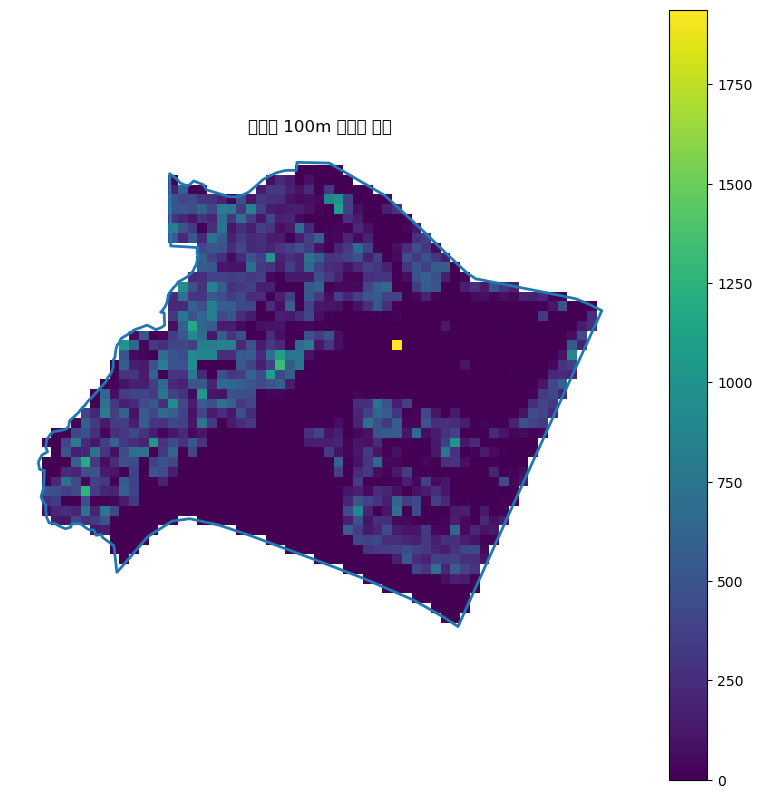

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))

seongdong.boundary.plot(
    ax=ax,
    linewidth=2
)

seongdong_grid.plot(
    ax=ax,
    column="population",
    legend=True
)

ax.set_title("성동구 100m 격자별 인구")
ax.set_axis_off()

plt.show()

In [12]:
# -------------------------------------------------
# 7. 인구가 있는 격자만 수요지로 사용
# -------------------------------------------------

demand = seongdong_grid.loc[
    seongdong_grid["population"] > 0
].copy()

# 격자 폴리곤을 중심점으로 변환
demand = gpd.GeoDataFrame(
    demand[
        ["GRID_CD", "population"]
    ],
    geometry=seongdong_grid.loc[
        seongdong_grid["population"] > 0,
        "centroid"
    ],
    crs=seongdong_grid.crs
)

demand.head()

,GRID_CD,population,geometry
371419,다사607484,81,POINT (960750 1948450)
371420,다사608484,177,POINT (960850 1948450)
371421,다사609484,144,POINT (960950 1948450)
372331,다사604485,396,POINT (960450 1948550)
372332,다사605485,290,POINT (960550 1948550)


In [13]:
# 기존 보행 네트워크 G를 EPSG:5179로 변환
G_proj = ox.project_graph(
    G,
    to_crs="EPSG:5179"
)

# 각 인구격자 중심점과 가장 가까운 네트워크 노드
demand["nearest_node"] = ox.distance.nearest_nodes(
    G_proj,
    X=demand.geometry.x,
    Y=demand.geometry.y
)

demand[
    ["GRID_CD", "population", "nearest_node"]
].head()

NameError: name 'G' is not defined

In [15]:
import osmnx as ox

# -------------------------------------------------
# 1. 성동구 경계를 EPSG:4326으로 변환
# -------------------------------------------------

seongdong_wgs84 = seongdong.to_crs("EPSG:4326")
polygon_wgs84 = seongdong_wgs84.geometry.union_all()

print("네트워크 다운로드용 경계 좌표계:", seongdong_wgs84.crs)


# -------------------------------------------------
# 2. 성동구 보행 네트워크 생성
# -------------------------------------------------

G = ox.graph_from_polygon(
    polygon_wgs84,
    network_type="walk",
    simplify=True
)

print(type(G))
print("노드 수:", len(G.nodes))
print("엣지 수:", len(G.edges))
print("원래 네트워크 좌표계:", G.graph["crs"])


# -------------------------------------------------
# 3. 인구격자와 같은 좌표계로 변환
# -------------------------------------------------

G_proj = ox.project_graph(
    G,
    to_crs=demand.crs
)

print("투영된 네트워크 좌표계:", G_proj.graph["crs"])
print("수요지 좌표계:", demand.crs)

네트워크 다운로드용 경계 좌표계: EPSG:4326
<class 'networkx.classes.multidigraph.MultiDiGraph'>
노드 수: 5586
엣지 수: 15870
원래 네트워크 좌표계: epsg:4326
투영된 네트워크 좌표계: EPSG:5179
수요지 좌표계: EPSG:5179


In [16]:
# -------------------------------------------------
# 4. 가장 가까운 네트워크 노드 연결
# -------------------------------------------------

nearest_nodes, snap_distances = ox.distance.nearest_nodes(
    G_proj,
    X=demand.geometry.x.to_numpy(),
    Y=demand.geometry.y.to_numpy(),
    return_dist=True
)

demand["nearest_node"] = nearest_nodes
demand["snap_distance_m"] = snap_distances

print(
    demand[
        ["GRID_CD", "population", "nearest_node", "snap_distance_m"]
    ].head()
)

print("\n수요지 수:", len(demand))
print("연결된 고유 네트워크 노드 수:", demand["nearest_node"].nunique())
print("\n네트워크 연결 거리 요약:")
print(demand["snap_distance_m"].describe())

         GRID_CD  population  nearest_node  snap_distance_m
371419  다사607484          81     600372011         9.851822
371420  다사608484         177    4179264045        15.113352
371421  다사609484         144    4179264048        45.290292
372331  다사604485         396    4179349672        64.316752
372332  다사605485         290    1855204526         5.557320

수요지 수: 937
연결된 고유 네트워크 노드 수: 913

네트워크 연결 거리 요약:
count    937.000000
mean      30.672686
std       20.010789
min        1.007089
25%       15.944268
50%       27.079069
75%       41.402189
max      130.159131
Name: snap_distance_m, dtype: float64


In [17]:
print(
    "네트워크에서 100m 이상 떨어진 수요지:",
    (demand["snap_distance_m"] >= 100).sum()
)

print(
    "네트워크에서 200m 이상 떨어진 수요지:",
    (demand["snap_distance_m"] >= 200).sum()
)

print(
    "최대 연결 거리:",
    demand["snap_distance_m"].max()
)

네트워크에서 100m 이상 떨어진 수요지: 9
네트워크에서 200m 이상 떨어진 수요지: 0
최대 연결 거리: 130.15913053776538


In [18]:
ox.save_graphml(
    G,
    filepath="seongdong_walk.graphml"
)